In [63]:
import xarray as xr, matplotlib, matplotlib.pyplot as plt, pandas as pd, geopandas as gpd, numpy as np, regionmask, cartopy, os, glob
from shapely.geometry import Polygon
from IPython.display import clear_output
from functools import reduce

# functions to download from GHCN-D
import sys; sys.path.append('/rds/general/user/cb2714/home/get-station-data'); 
from get_station_data import ghcnd
from get_station_data.util import nearest_stn

# study region
box1_x = [-70, -70, -105, -105, -70]
box1_y = [46, 39, 30, 37, 46]
gdf1 = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[Polygon(list(zip(box1_x, box1_y)))])

# path to data on ephemeral
fpath = "/rds/general/user/cb2714/home/00_WWA_project_folder/ephemeral/us-snow/obs/ghcn-d"

# Station data

## Identify GHCN-D candidate stations

In [ ]:
# import all metadata
stn_md = ghcnd.get_stn_metadata()

In [ ]:
stn_md

In [ ]:
px = gpd.GeoDataFrame(stn_md, geometry = gpd.points_from_xy(stn_md.lon, stn_md.lat), crs = "EPSG:4326").clip(gdf1)
px = px.loc[(px.end_year == 2026) & (px.start_year <= 1950)]

In [30]:
px.to_csv(fpath+"/00_station-metadata.csv", index = None)

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


<GeoAxes: >

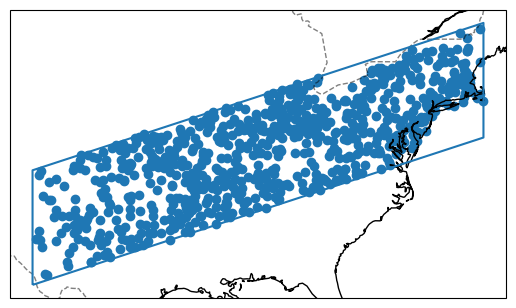

In [69]:
fig, ax = plt.subplots(subplot_kw = {"projection" : cartopy.crs.PlateCarree()})
gdf1.boundary.plot(ax = ax)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
px.plot(ax = ax)

## Loop over stations & download

In [6]:
px = pd.read_csv(fpath+"/00_station-metadata.csv")

In [ ]:
for i in range(len(px)):
    print(i, "/", len(px))
    r = px.iloc[[i]]
    new_fnm = fpath+"/stn_"+r.station.values[0]+".csv"
    if os.path.exists(new_fnm): continue

    # faster to download without flags, but no QA - should check this in final station selection
    ghcnd.get_data(r, element_types = ["SNOW", "PRCP", "TMAX", "TMIN"], include_flags = False).to_csv(new_fnm, index = None)
    clear_output(wait = False)
print("Done.")

## Update metadata for each variable

In [10]:
md = []
for fnm in glob.glob(fpath+"/stn_*.csv"):
    
    stn = fnm.split("_")[-1][:-4]
    df = pd.read_csv(fnm, parse_dates = ["date"])

    # extract data
    min_date = pd.crosstab(index = df.station, columns = df.element, values = df.date, aggfunc = "min")
    max_date = pd.crosstab(index = df.station, columns = df.element, values = df.date, aggfunc = "max")
    counts = pd.crosstab(index = df.station, columns = df.element)
    prop =  counts / ((max_date - min_date ).iloc[0].dt.days + 1)
    years = counts / 365.25

    summ = pd.concat([min_date, max_date, counts, prop, years], axis=1)
    
    summ.columns = [c+"_"+s for c, s in zip(summ.columns, np.repeat(["start", "end", "nobs", "prop", "years"],len(counts.columns)))] # columns have to be non-unique to merge
    md.append(summ)
md = pd.concat(md)
md.to_csv(fpath+"/00_station-availability.csv")

## Compile metadata

In [11]:
# compile
px = pd.read_csv(fpath+"/00_station-metadata.csv", index_col = "station")
av = pd.read_csv(fpath+"/00_station-availability.csv", index_col = "station")
df = pd.merge(px, av, left_index = True, right_index = True)

df.to_csv(fpath+"/00_station-metadata-with-availability.csv")

## Filter metadata

In [12]:
px = pd.read_csv(fpath+"/00_station-metadata-with-availability.csv", index_col = "station")
px = gpd.GeoDataFrame(px, geometry = gpd.points_from_xy(px.lon, px.lat), crs = "EPSG:4326")

In [ ]:
px_snow = px.loc[(px.SNOW_prop ==1) & (px.SNOW_years > 50) & (px.SNOW_end >= "2026-02-01")]

In [40]:
px_snow.to_csv(fpath+"/01_stations-with-complete-data.csv")

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


<GeoAxes: >

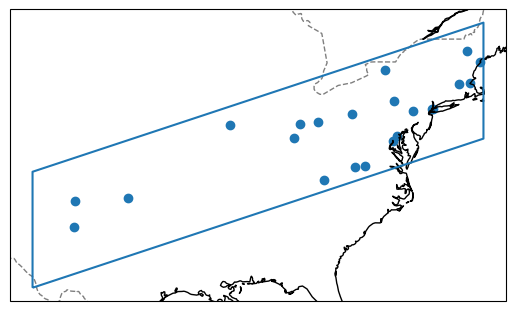

In [20]:
fig, ax = plt.subplots(subplot_kw = {"projection" : cartopy.crs.PlateCarree()})
gdf1.boundary.plot(ax = ax)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
px_snow.plot(ax = ax)

## Reshape data at selected stations

In [67]:
px_complete = pd.read_csv(fpath+"/01_stations-with-complete-data.csv", index_col = "station")

In [68]:
# load each dataframe & reshape to wide df with all variables
for stn in px_complete.index:
    
    df = pd.read_csv(fpath+"/stn_"+stn+".csv", index_col = "date", parse_dates = ["date"]).dropna(axis = 0, how = "any")
    df_w = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), [df.loc[df.element == e].rename(columns = {"value" : e})[[e]] for e in ["SNOW", "PRCP", "TMAX", "TMIN"]])
    df_w.to_csv(fpath+"_complete/stn_"+stn+".csv")